# 🌊 FloodGuard Jakarta - ML Model Training
### Prediksi Banjir Jakarta menggunakan Machine Learning

**Dataset:** Indonesia Flood Data (BMKG 2016-2020)

**Target:** Prediksi banjir berdasarkan data cuaca

## 1. Import Libraries

In [ ]:
# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer

# Handle imbalanced data
from imblearn.over_sampling import SMOTE

# Model saving
import pickle

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load Dataset

In [ ]:
# Load dataset
df = pd.read_csv('data_finish.csv')

print(f"   Shape: {df.shape}")
print(f"   Periode: {df['date'].min()} to {df['date'].max()}")

df.head()

   Shape: (6308, 15)
   Periode: 2016-01-01 to 2020-12-31


,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id,station_name,region_name,flood
0,2016-01-01,26.0,34.8,28.6,81.0,NaN,5.8,5.0,280.0,2.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
1,2016-01-02,25.6,33.2,27.0,88.0,1.6,8.7,4.0,290.0,2.0,W,96733,Stasiun Klimatologi Banten,Jakarta Selatan,1
2,2016-01-03,24.4,34.9,28.1,80.0,33.8,5.4,4.0,280.0,2.0,SW,96733,Stasiun Klimatologi Banten,Jakarta Selatan,1
3,2016-01-04,24.8,33.6,29.2,81.0,NaN,6.6,3.0,200.0,1.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
4,2016-01-05,25.8,33.6,26.7,91.0,NaN,3.2,3.0,180.0,1.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0


## 3. Exploratory Data Analysis (EDA)

In [ ]:
# Basic info
print("📋 Dataset Info:")
print(df.info())

print("\n" + "="*70)
print("📊 Statistical Summary:")
print(df.describe())

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6308 entries, 0 to 6307
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          6308 non-null   object 
 1   Tn            5996 non-null   float64
 2   Tx            6095 non-null   float64
 3   Tavg          6262 non-null   float64
 4   RH_avg        6256 non-null   float64
 5   RR            3993 non-null   float64
 6   ss            5049 non-null   float64
 7   ff_x          6286 non-null   float64
 8   ddd_x         6286 non-null   float64
 9   ff_avg        6215 non-null   float64
 10  ddd_car       6207 non-null   object 
 11  station_id    6308 non-null   int64  
 12  station_name  6308 non-null   object 
 13  region_name   6308 non-null   object 
 14  flood         6308 non-null   int64  
dtypes: float64(9), int64(2), object(4)
memory usage: 739.3+ KB
None

📊 Statistical Summary:
                Tn           Tx         Tavg       RH

In [ ]:
# Check missing values
print("⚠️ Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

⚠️ Missing Values:
         Missing Count  Percentage
RR                2315   36.699429
ss                1259   19.958782
Tn                 312    4.946100
Tx                 213    3.376665
ddd_car            101    1.601141
ff_avg              93    1.474318
RH_avg              52    0.824350
Tavg                46    0.729233
ddd_x               22    0.348763
ff_x                22    0.348763


🌊 Flood Distribution:
flood
0    5832
1     476
Name: count, dtype: int64

Flood percentage: 7.55%


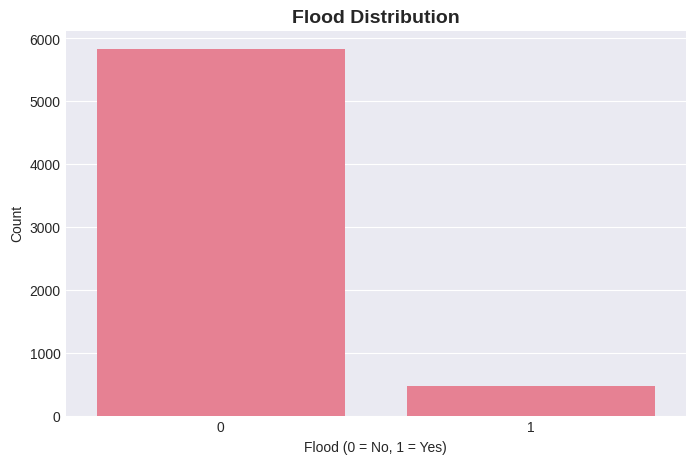

In [ ]:
# Flood distribution
print("🌊 Flood Distribution:")
print(df['flood'].value_counts())
print(f"\nFlood percentage: {(df['flood'].sum()/len(df)*100):.2f}%")

# Visualize
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='flood')
plt.title('Flood Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Flood (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

📍 Flood by Region:
                 Total Floods  Total Records  Flood Rate
region_name                                             
Jakarta Timur             147           1057    0.139073
Jakarta Selatan           209           1658    0.126055
Jakarta Utara              98           1779    0.055087
Jakarta Pusat              22           1814    0.012128


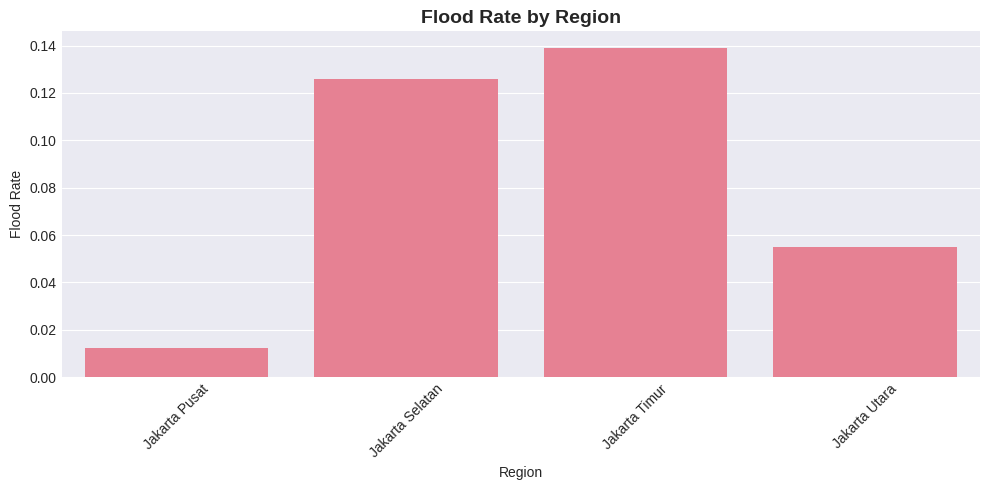

In [ ]:
# Region distribution
print("📍 Flood by Region:")
region_flood = df.groupby('region_name')['flood'].agg(['sum', 'count', 'mean'])
region_flood.columns = ['Total Floods', 'Total Records', 'Flood Rate']
print(region_flood.sort_values('Flood Rate', ascending=False))

# Visualize
plt.figure(figsize=(10, 5))
sns.barplot(data=df.groupby('region_name')['flood'].mean().reset_index(),
            x='region_name', y='flood')
plt.title('Flood Rate by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Flood Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

🔗 Correlation with Flood:
flood     1.000000
RR        0.282177
RH_avg    0.202915
ff_avg    0.012995
ff_x     -0.002889
Tx       -0.043503
Tn       -0.057939
ss       -0.081076
Tavg     -0.161414
Name: flood, dtype: float64


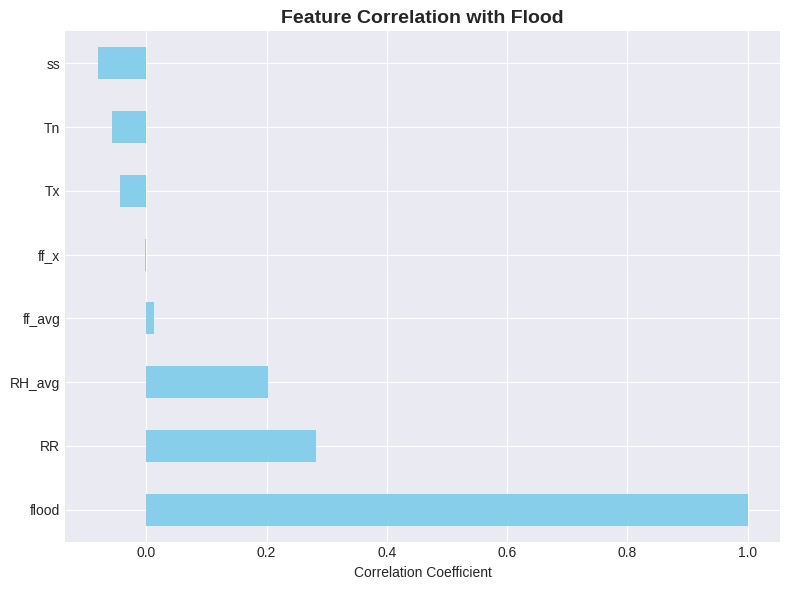

In [ ]:
# Correlation with flood
numeric_cols = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x', 'ff_avg']
correlation = df[numeric_cols + ['flood']].corr()['flood'].sort_values(ascending=False)

print("🔗 Correlation with Flood:")
print(correlation)

# Visualize
plt.figure(figsize=(8, 6))
correlation[:-1].plot(kind='barh', color='skyblue')
plt.title('Feature Correlation with Flood', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

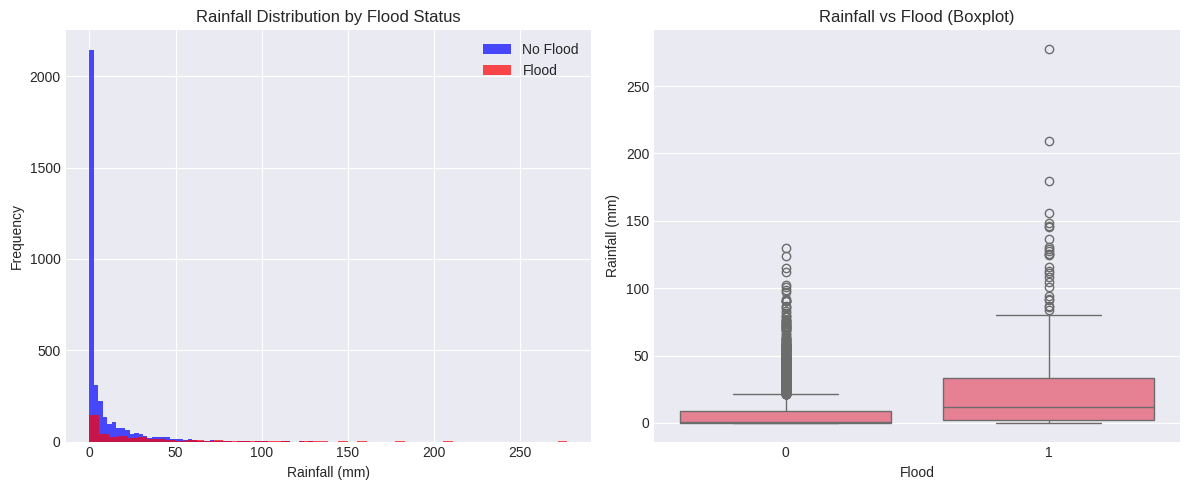

In [ ]:
# Rainfall vs Flood
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df[df['flood'] == 0]['RR'].hist(bins=50, alpha=0.7, label='No Flood', color='blue')
df[df['flood'] == 1]['RR'].hist(bins=50, alpha=0.7, label='Flood', color='red')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.title('Rainfall Distribution by Flood Status')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='flood', y='RR')
plt.xlabel('Flood')
plt.ylabel('Rainfall (mm)')
plt.title('Rainfall vs Flood (Boxplot)')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [ ]:
# Create a copy for processing
df_clean = df.copy()

print("🧹 Starting data cleaning...")
print(f"Original shape: {df_clean.shape}")

🧹 Starting data cleaning...
Original shape: (6308, 15)


In [ ]:
# Handle outliers (values yang tidak masuk akal)
# Temperature harus 20-40°C, Humidity 0-100%

df_clean = df_clean[
    (df_clean['Tn'] < 50) & (df_clean['Tn'] > 15) |
    (df_clean['Tn'].isnull())
]

df_clean = df_clean[
    (df_clean['Tx'] < 50) & (df_clean['Tx'] > 20) |
    (df_clean['Tx'].isnull())
]

df_clean = df_clean[
    (df_clean['RH_avg'] <= 100) & (df_clean['RH_avg'] >= 0) |
    (df_clean['RH_avg'].isnull())
]

print(f"After removing outliers: {df_clean.shape}")
print(f"Removed {len(df) - len(df_clean)} outlier records")

After removing outliers: (6299, 15)
Removed 9 outlier records


In [ ]:
# Select features for modeling
feature_cols = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x', 'ff_avg']
target_col = 'flood'

# Create X and y
X = df_clean[feature_cols].copy()
y = df_clean[target_col].copy()

print(f"Features: {feature_cols}")
print(f"Target: {target_col}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Features: ['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x', 'ff_avg']
Target: flood
X shape: (6299, 8)
y shape: (6299,)


In [ ]:
# Handle missing values dengan imputation
print("🔧 Handling missing values...")

# Impute dengan median (robust terhadap outliers)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=feature_cols)

print(f"Missing values after imputation:")
print(X.isnull().sum())

🔧 Handling missing values...
Missing values after imputation:
Tn        0
Tx        0
Tavg      0
RH_avg    0
RR        0
ss        0
ff_x      0
ff_avg    0
dtype: int64


In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Data split completed:")
print(f"   Training set: {X_train.shape}")
print(f"   Test set: {X_test.shape}")
print(f"   Train flood rate: {y_train.mean():.2%}")
print(f"   Test flood rate: {y_test.mean():.2%}")

✅ Data split completed:
   Training set: (5039, 8)
   Test set: (1260, 8)
   Train flood rate: 7.56%
   Test flood rate: 7.54%


In [ ]:
# Handle imbalanced data dengan SMOTE
print("⚖️ Handling class imbalance with SMOTE...")
print(f"Before SMOTE:")
print(f"   Class 0: {(y_train == 0).sum()}")
print(f"   Class 1: {(y_train == 1).sum()}")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"   Class 0: {(y_train_balanced == 0).sum()}")
print(f"   Class 1: {(y_train_balanced == 1).sum()}")

⚖️ Handling class imbalance with SMOTE...
Before SMOTE:
   Class 0: 4658
   Class 1: 381

After SMOTE:
   Class 0: 4658
   Class 1: 4658


In [ ]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed!")

✅ Feature scaling completed!


## 5. Model Training

### 5.1 Random Forest Classifier

In [ ]:
print("🌲 Training Random Forest model...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train_balanced)

print("✅ Random Forest training completed!")

🌲 Training Random Forest model...
✅ Random Forest training completed!


### 5.2 Gradient Boosting Classifier

In [ ]:
print("🚀 Training Gradient Boosting model...")

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train_balanced)

print("✅ Gradient Boosting training completed!")

🚀 Training Gradient Boosting model...
✅ Gradient Boosting training completed!


## 6. Model Evaluation

In [ ]:
# Predictions
rf_pred = rf_model.predict(X_test_scaled)
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

gb_pred = gb_model.predict(X_test_scaled)
gb_pred_proba = gb_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Predictions generated!")

✅ Predictions generated!


In [ ]:
# Evaluate Random Forest
print("=" * 70)
print("🌲 RANDOM FOREST EVALUATION")
print("=" * 70)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_pred_proba)

print(f"Accuracy: {rf_accuracy:.4f}")
print(f"AUC-ROC: {rf_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['No Flood', 'Flood']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

🌲 RANDOM FOREST EVALUATION
Accuracy: 0.8849
AUC-ROC: 0.7985

Classification Report:
              precision    recall  f1-score   support

    No Flood       0.94      0.94      0.94      1165
       Flood       0.25      0.26      0.26        95

    accuracy                           0.88      1260
   macro avg       0.59      0.60      0.60      1260
weighted avg       0.89      0.88      0.89      1260


Confusion Matrix:
[[1090   75]
 [  70   25]]


In [ ]:
# Evaluate Gradient Boosting
print("=" * 70)
print("🚀 GRADIENT BOOSTING EVALUATION")
print("=" * 70)

gb_accuracy = accuracy_score(y_test, gb_pred)
gb_auc = roc_auc_score(y_test, gb_pred_proba)

print(f"Accuracy: {gb_accuracy:.4f}")
print(f"AUC-ROC: {gb_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, gb_pred, target_names=['No Flood', 'Flood']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

🚀 GRADIENT BOOSTING EVALUATION
Accuracy: 0.9032
AUC-ROC: 0.7830

Classification Report:
              precision    recall  f1-score   support

    No Flood       0.94      0.96      0.95      1165
       Flood       0.29      0.20      0.24        95

    accuracy                           0.90      1260
   macro avg       0.61      0.58      0.59      1260
weighted avg       0.89      0.90      0.89      1260


Confusion Matrix:
[[1119   46]
 [  76   19]]


📊 MODEL COMPARISON
               Model  Accuracy   AUC-ROC
0      Random Forest  0.884921  0.798455
1  Gradient Boosting  0.903175  0.782968


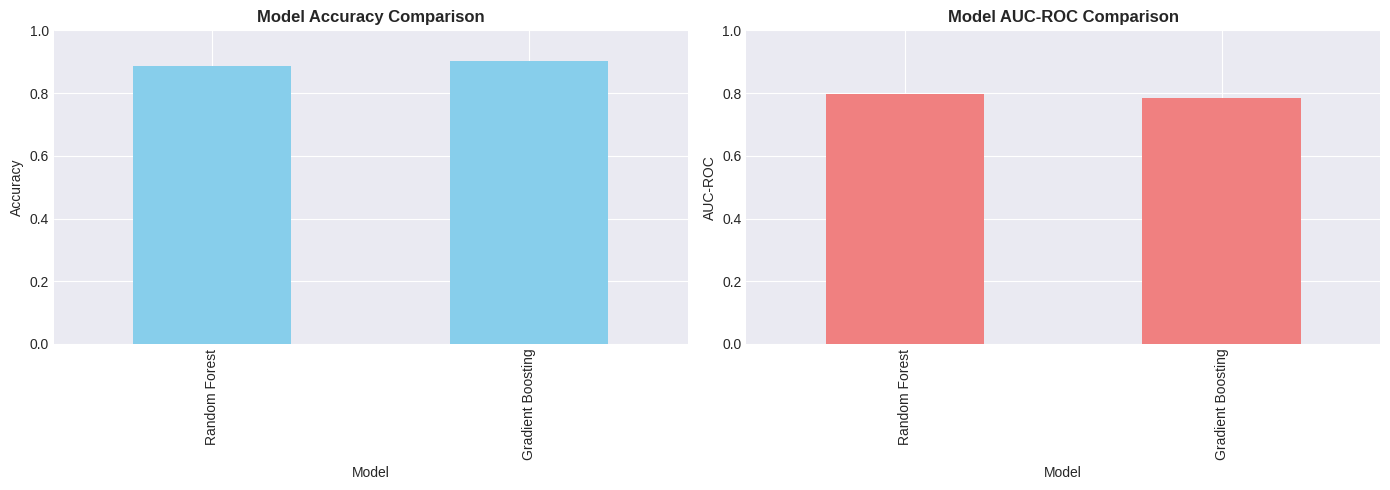

In [ ]:
# Compare models
print("=" * 70)
print("📊 MODEL COMPARISON")
print("=" * 70)

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'Accuracy': [rf_accuracy, gb_accuracy],
    'AUC-ROC': [rf_auc, gb_auc]
})

print(comparison)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison.plot(x='Model', y='Accuracy', kind='bar', ax=axes[0], color='skyblue', legend=False)
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])

comparison.plot(x='Model', y='AUC-ROC', kind='bar', ax=axes[1], color='lightcoral', legend=False)
axes[1].set_title('Model AUC-ROC Comparison', fontweight='bold')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

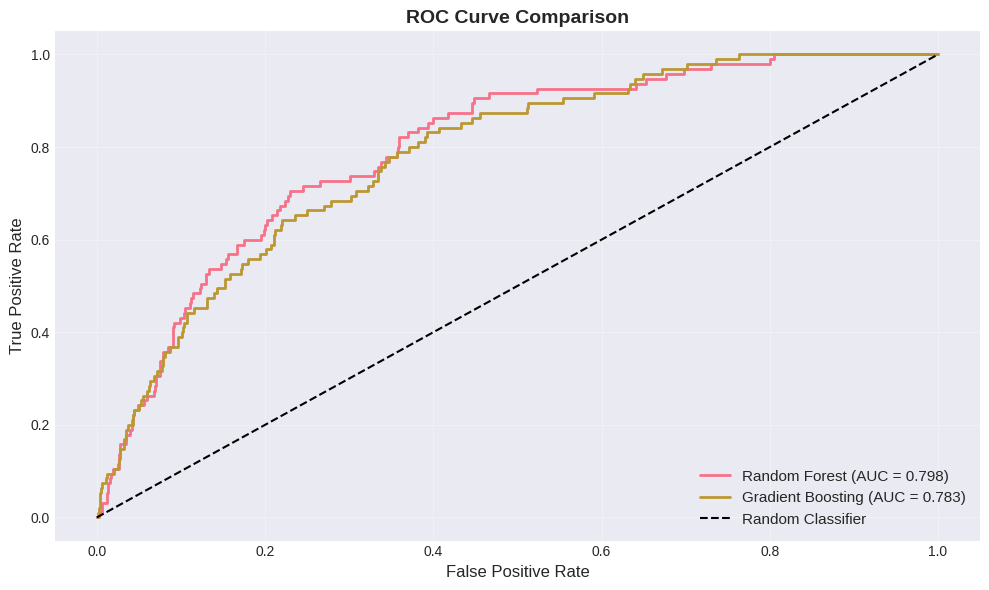

In [ ]:
# ROC Curve
plt.figure(figsize=(10, 6))

# Random Forest ROC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_proba)
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})', linewidth=2)

# Gradient Boosting ROC
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_pred_proba)
plt.plot(gb_fpr, gb_tpr, label=f'Gradient Boosting (AUC = {gb_auc:.3f})', linewidth=2)

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

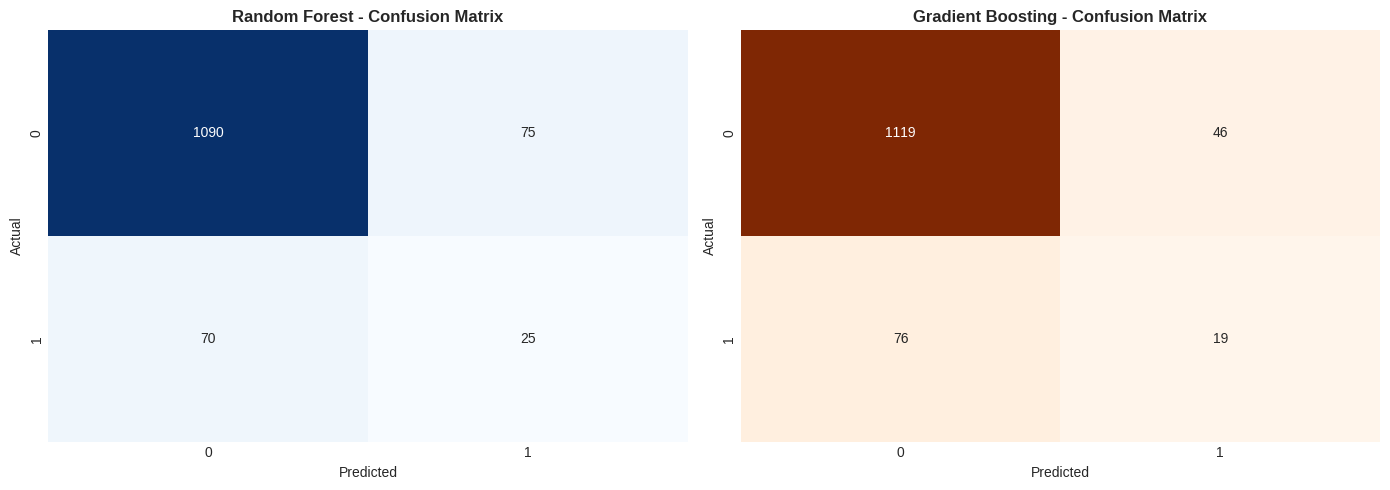

In [ ]:
# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues',
            ax=axes[0], cbar=False)
axes[0].set_title('Random Forest - Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Gradient Boosting
sns.heatmap(confusion_matrix(y_test, gb_pred), annot=True, fmt='d', cmap='Oranges',
            ax=axes[1], cbar=False)
axes[1].set_title('Gradient Boosting - Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 7. Feature Importance

🌲 Random Forest - Feature Importance:
  Feature  Importance
3  RH_avg    0.236481
0      Tn    0.165315
2    Tavg    0.160700
4      RR    0.127261
7  ff_avg    0.090498
6    ff_x    0.077235
5      ss    0.072913
1      Tx    0.069597


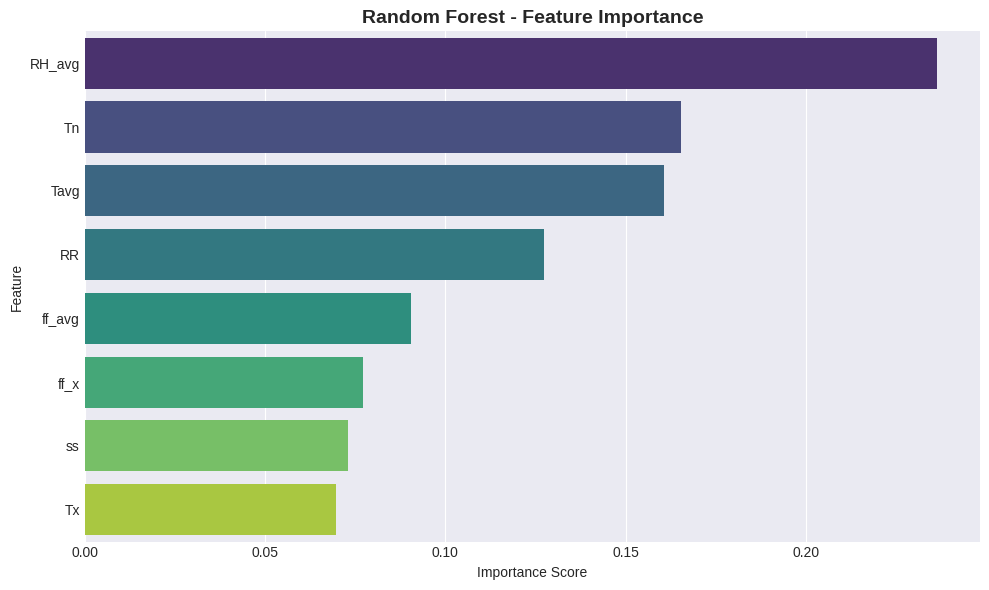

In [ ]:
# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("🌲 Random Forest - Feature Importance:")
print(rf_importance)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

🚀 Gradient Boosting - Feature Importance:
  Feature  Importance
3  RH_avg    0.426781
0      Tn    0.171550
6    ff_x    0.111513
7  ff_avg    0.110916
4      RR    0.079893
2    Tavg    0.034073
1      Tx    0.033272
5      ss    0.032003


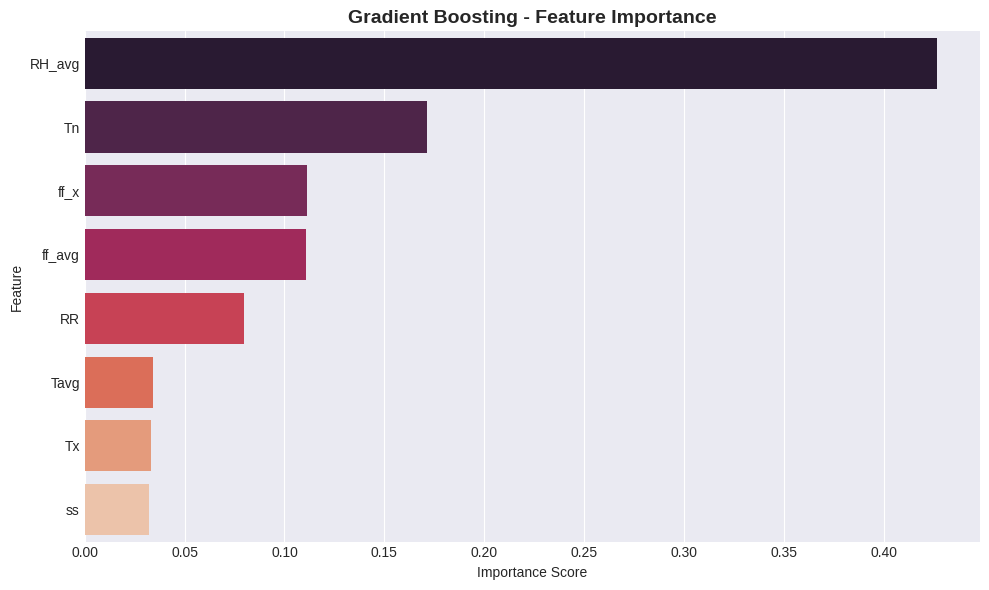

In [ ]:
# Gradient Boosting Feature Importance
gb_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("🚀 Gradient Boosting - Feature Importance:")
print(gb_importance)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=gb_importance, x='Importance', y='Feature', palette='rocket')
plt.title('Gradient Boosting - Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 8. Select Best Model & Save

In [ ]:
# Select best model berdasarkan AUC-ROC
if rf_auc > gb_auc:
    best_model = rf_model
    best_model_name = 'Random Forest'
    best_auc = rf_auc
    best_accuracy = rf_accuracy
else:
    best_model = gb_model
    best_model_name = 'Gradient Boosting'
    best_auc = gb_auc
    best_accuracy = gb_accuracy

print("=" * 70)
print(f"🏆 BEST MODEL: {best_model_name}")
print("=" * 70)
print(f"Accuracy: {best_accuracy:.4f}")
print(f"AUC-ROC: {best_auc:.4f}")

🏆 BEST MODEL: Random Forest
Accuracy: 0.8849
AUC-ROC: 0.7985


In [ ]:
# Save model, scaler, dan imputer
print("💾 Saving model, scaler, and imputer...")

# Save best model
with open('flood_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save imputer
with open('imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)

# Save feature names
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("✅ All files saved successfully!")
print("   - flood_model.pkl")
print("   - scaler.pkl")
print("   - imputer.pkl")
print("   - feature_names.pkl")

💾 Saving model, scaler, and imputer...
✅ All files saved successfully!
   - flood_model.pkl
   - scaler.pkl
   - imputer.pkl
   - feature_names.pkl


## 9. Test Prediction Function

In [ ]:
def predict_flood(Tn, Tx, Tavg, RH_avg, RR, ss, ff_x, ff_avg):
    """
    Predict flood probability based on weather conditions

    Parameters:
    - Tn: Min temperature (°C)
    - Tx: Max temperature (°C)
    - Tavg: Avg temperature (°C)
    - RH_avg: Avg humidity (%)
    - RR: Rainfall (mm)
    - ss: Sunshine duration (hours)
    - ff_x: Max wind speed (m/s)
    - ff_avg: Avg wind speed (m/s)

    Returns:
    - prediction: 0 (No Flood) or 1 (Flood)
    - probability: Flood probability (0-1)
    - risk_level: Low, Medium, or High
    """
    # Prepare input
    input_data = pd.DataFrame({
        'Tn': [Tn],
        'Tx': [Tx],
        'Tavg': [Tavg],
        'RH_avg': [RH_avg],
        'RR': [RR],
        'ss': [ss],
        'ff_x': [ff_x],
        'ff_avg': [ff_avg]
    })

    # Impute missing values
    input_imputed = imputer.transform(input_data)

    # Scale features
    input_scaled = scaler.transform(input_imputed)

    # Predict
    prediction = best_model.predict(input_scaled)[0]
    probability = best_model.predict_proba(input_scaled)[0][1]

    # Determine risk level
    if probability < 0.3:
        risk_level = 'Low'
    elif probability < 0.7:
        risk_level = 'Medium'
    else:
        risk_level = 'High'

    return {
        'prediction': int(prediction),
        'probability': float(probability),
        'risk_level': risk_level
    }

print("✅ Prediction function ready!")

✅ Prediction function ready!


In [ ]:
# Test dengan contoh data
print("🧪 Testing prediction function...\n")

# Test case 1: High risk (heavy rain)
print("Test Case 1: Heavy Rain")
result1 = predict_flood(
    Tn=25.0, Tx=30.0, Tavg=27.5,
    RH_avg=85.0, RR=80.0,  # Heavy rainfall
    ss=2.0, ff_x=5.0, ff_avg=3.0
)
print(f"   Prediction: {'Flood' if result1['prediction'] == 1 else 'No Flood'}")
print(f"   Probability: {result1['probability']:.2%}")
print(f"   Risk Level: {result1['risk_level']}")

# Test case 2: Low risk (no rain)
print("\nTest Case 2: Clear Weather")
result2 = predict_flood(
    Tn=24.0, Tx=32.0, Tavg=28.0,
    RH_avg=70.0, RR=0.0,  # No rain
    ss=8.0, ff_x=3.0, ff_avg=2.0
)
print(f"   Prediction: {'Flood' if result2['prediction'] == 1 else 'No Flood'}")
print(f"   Probability: {result2['probability']:.2%}")
print(f"   Risk Level: {result2['risk_level']}")

# Test case 3: Medium risk
print("\nTest Case 3: Moderate Rain")
result3 = predict_flood(
    Tn=25.5, Tx=31.0, Tavg=28.0,
    RH_avg=78.0, RR=25.0,  # Moderate rain
    ss=5.0, ff_x=4.0, ff_avg=2.5
)
print(f"   Prediction: {'Flood' if result3['prediction'] == 1 else 'No Flood'}")
print(f"   Probability: {result3['probability']:.2%}")
print(f"   Risk Level: {result3['risk_level']}")

🧪 Testing prediction function...

Test Case 1: Heavy Rain
   Prediction: No Flood
   Probability: 48.42%
   Risk Level: Medium

Test Case 2: Clear Weather
   Prediction: No Flood
   Probability: 3.08%
   Risk Level: Low

Test Case 3: Moderate Rain
   Prediction: No Flood
   Probability: 17.46%
   Risk Level: Low


## 10. Download Model Files

In [ ]:
# Download files (untuk Colab)
# from google.colab import files

# files.download('flood_model.pkl')
# files.download('scaler.pkl')
# files.download('imputer.pkl')
# files.download('feature_names.pkl')

print("📥 Download the following files:")
print("   1. flood_model.pkl")
print("   2. scaler.pkl")
print("   3. imputer.pkl")
print("   4. feature_names.pkl")
print("\n✅ Training completed successfully!")
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.2%}")
print(f"   AUC-ROC: {best_auc:.4f}")

📥 Download the following files:
   1. flood_model.pkl
   2. scaler.pkl
   3. imputer.pkl
   4. feature_names.pkl

✅ Training completed successfully!

🏆 Best Model: Random Forest
   Accuracy: 88.49%
   AUC-ROC: 0.7985


---
## 📝 Summary

**Model Performance:**
- Best model akan dipilih berdasarkan AUC-ROC score
- Model di-save dalam format `.pkl` untuk digunakan di production
- Feature importance menunjukkan **Rainfall (RR)** sebagai predictor terpenting

**Next Steps:**
1. Download semua file `.pkl`
2. Integrasikan dengan Flask API (Python backend)
3. Connect dengan PHP untuk web application
4. Deploy ke production server

**Files to use in production:**
- `flood_model.pkl` - Trained ML model
- `scaler.pkl` - Feature scaler
- `imputer.pkl` - Missing value imputer
- `feature_names.pkl` - Feature column names